<a href="https://colab.research.google.com/github/inmira/E-Commerce-Sales-ETL-Analytics-Pipeline/blob/main/E_Commerce_Sales_ETL_%26_Analytics_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Overview

The goal of this project was to build an end-to-end ETL and analytics pipeline for e-commerce sales data using Python, SQL, and SQLite.

The project focused on:
- data extraction and integration from multiple datasets,
- data cleaning and validation,
- feature engineering and analytical dataset creation,
- loading transformed data into a relational database,
- performing SQL-based business analysis,
- creating visualizations to support reporting and decision-making.

The final analytical dataset was used to analyze revenue trends, customer geography, product categories, and transactional behavior.

### Setup and Data Loading

First, let's ensure all necessary libraries are imported and initialize the `dfs` dictionary to store our DataFrames.

In [94]:
import pandas as pd
import gdown
import os

# Create a dictionary to hold all DataFrames
dfs = {}

# Define the directory for storing data files
data_path = 'S_Data'
os.makedirs(data_path, exist_ok=True)


In [95]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import re
from wordcloud import WordCloud
import plotly.graph_objects as go

Now, let's download the other required Olist dataset files. These are common public datasets, so I'll provide general Google Drive links. If these specific links don't work, you may need to find updated ones for these files:

- `olist_orders_dataset.csv`
- `olist_products_dataset.csv`
- `olist_order_items_dataset.csv`
- `olist_order_payments_dataset.csv`
- `olist_order_customers_dataset.csv`

In [97]:

file_urls = {
    'orders.csv': 'https://drive.google.com/uc?id=1O3IqZTjiAYF7cHFu41gnrUAxHqdbtlhP',
    'products.csv': 'https://drive.google.com/uc?id=12F0wLr-yOwQt07wmwwzKQFqvn0wxXoLf',
    'order_items.csv': 'https://drive.google.com/uc?id=1c-zjSNrwUR4ec0UVAnIojzY96HPJvpB8',
    'order_payments.csv': 'https://drive.google.com/uc?id=1CuZILmyGWICxHsGP_SahpGDGmUdn3WwY',
    'customers.csv': 'https://drive.google.com/uc?id=1vB7CYMX1BPiW-eEH_KGyJiIwV1Jzjg7Q' # New: customers.csv
}

# Download and save each file
print("Attempting to download and load Olist datasets:")
for file_name, url in file_urls.items():
    output_path = os.path.join(data_path, file_name)
    print(f"Downloading {file_name} to {output_path}...")
    try:
        # Skip download if URL is still a placeholder
        if '[YOUR_GOOGLE_DRIVE_ID_HERE]' in url:
            print(f"Skipping download for {file_name} as the URL is a placeholder. Please update it.")
            dfs[os.path.join('S_Data', file_name)] = pd.DataFrame() # Assign empty DataFrame
            continue

        gdown.download(url, output_path, quiet=False)
        # Load the downloaded CSV into the dfs dictionary
        dfs[os.path.join('S_Data', file_name)] = pd.read_csv(output_path, encoding='iso-8859-1')
        print(f"Loaded 'S_Data/{file_name}' into dfs")
        print(dfs[os.path.join('S_Data', file_name)].head())
    except Exception as e:
        print(f"Could not download or load {file_name} from {url}. Error: {e}")
        print("Please ensure the Google Drive ID is correct and the file is publicly accessible or shared with your account.")
        dfs[os.path.join('S_Data', file_name)] = pd.DataFrame() # Assign empty DataFrame on failure

print("\n--- Current state of dfs after attempted loading ---")
for key, value in dfs.items():
    if not value.empty:
        print(f"'{key}' loaded successfully with {len(value)} rows.")
    else:
        print(f"'{key}' is empty or failed to load.")


Attempting to download and load Olist datasets:


Downloading...
From: https://drive.google.com/uc?id=1O3IqZTjiAYF7cHFu41gnrUAxHqdbtlhP
To: /content/S_Data/orders.csv
100%|██████████| 17.7M/17.7M [00:00<00:00, 109MB/s]


Loaded 'S_Data/orders.csv' into dfs
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2

Downloading...
From: https://drive.google.com/uc?id=12F0wLr-yOwQt07wmwwzKQFqvn0wxXoLf
To: /content/S_Data/products.csv
100%|██████████| 2.38M/2.38M [00:00<00:00, 28.2MB/s]


Loaded 'S_Data/products.csv' into dfs
                         product_id  product_category_name  \
0  1e9e8ef04dbcff4541ed26657ea517e5             perfumaria   
1  3aa071139cb16b67ca9e5dea641aaa2f                  artes   
2  96bd76ec8810374ed1b65e291975717f          esporte_lazer   
3  cef67bcfe19066a932b7673e239eb23d                  bebes   
4  9dc1a7de274444849c219cff195d0b71  utilidades_domesticas   

   product_name_lenght  product_description_lenght  product_photos_qty  \
0                 40.0                       287.0                 1.0   
1                 44.0                       276.0                 1.0   
2                 46.0                       250.0                 1.0   
3                 27.0                       261.0                 1.0   
4                 37.0                       402.0                 4.0   

   product_weight_g  product_length_cm  product_height_cm  product_width_cm  
0             225.0               16.0               10.0         

...

Loaded 'S_Data/order_items.csv' into dfs
                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   
3  00024acbcdf0a6daa1e931b038114c75              1   
4  00042b26cf59d7ce69dfabb4e55b4fd9              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   
3  7634da152a4610f1595efa32f14722fc  9d7a1d34a5052409006425275ba1c2b4   
4  ac6c3623068f30de03045865e4e10089  df560393f3a51e74553ab94004ba5c87   

   shipping_limit_date   price  freight_value  
0  2017-09-19 09:45:35   58.90          13.29  
1  2017-05-03 11:05:13  239.90          19.93  
2  2018-01-18 14:48:30  199.00          17.87  
3  

Downloading...
From: https://drive.google.com/uc?id=1CuZILmyGWICxHsGP_SahpGDGmUdn3WwY
To: /content/S_Data/order_payments.csv
100%|██████████| 5.78M/5.78M [00:00<00:00, 33.1MB/s]


Loaded 'S_Data/order_payments.csv' into dfs
                           order_id  payment_sequential payment_type  \
0  b81ef226f3fe1789b1e8b2acac839d17                   1  credit_card   
1  a9810da82917af2d9aefd1278f1dcfa0                   1  credit_card   
2  25e8ea4e93396b6fa0d3dd708e76c1bd                   1  credit_card   
3  ba78997921bbcdc1373bb41e913ab953                   1  credit_card   
4  42fdf880ba16b47b59251dd489d4441a                   1  credit_card   

   payment_installments  payment_value  
0                     8          99.33  
1                     1          24.39  
2                     1          65.71  
3                     8         107.78  
4                     2         128.45  


Downloading...
From: https://drive.google.com/uc?id=1vB7CYMX1BPiW-eEH_KGyJiIwV1Jzjg7Q
To: /content/S_Data/customers.csv
100%|██████████| 9.03M/9.03M [00:00<00:00, 20.7MB/s]


Loaded 'S_Data/customers.csv' into dfs
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  

--- Current state of dfs after attempted loading ---
'S_Data/sellers.csv' loaded successfully with 3095 rows.
'S_

### Creating Individual DataFrames from the `dfs` Dictionary

Now, let's create individual DataFrame variables for easier access to each Olist dataset.

In [98]:
# Assign DataFrames from the dfs dictionary to individual variables
orders = dfs.get('S_Data/orders.csv', pd.DataFrame())
customers = dfs.get('S_Data/customers.csv', pd.DataFrame())
items = dfs.get('S_Data/order_items.csv', pd.DataFrame())
payments = dfs.get('S_Data/order_payments.csv', pd.DataFrame())
products = dfs.get('S_Data/products.csv', pd.DataFrame())

print("--- Orders DataFrame ---")
display(orders.head())

print("\n--- Customers DataFrame ---")
display(customers.head())

print("\n--- Items DataFrame ---")
display(items.head())

print("\n--- Payments DataFrame ---")
display(payments.head())

print("\n--- Products DataFrame ---")
display(products.head())

--- Orders DataFrame ---


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



--- Customers DataFrame ---


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



--- Items DataFrame ---


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



--- Payments DataFrame ---


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45



--- Products DataFrame ---


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [99]:

#1. Missing values
print(products.isnull().sum())


product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


In [100]:
products['product_category_name'] = products['product_category_name'].fillna('unknown')

In [101]:
numeric_product_cols = [
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

for col in numeric_product_cols:
    products[col] = products[col].fillna(products[col].median())

In [102]:
products.isnull().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0


Missing values in product categories were replaced with "unknown".  
Numerical product attributes were filled using median values to preserve data consistency and avoid removing valid product records.

In [103]:
products.duplicated().sum()

np.int64(0)

In [104]:
orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


Missing values in order date columns were not filled artificially, because they represent real business events such as orders that were not approved, shipped, or delivered. These values were kept as missing to preserve the original order lifecycle information.

In [105]:
orders.groupby('order_status')[
    ['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date']
].apply(lambda x: x.isnull().sum())

,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
order_status,,,
approved,0,2,2
canceled,141,550,619
created,5,5,5
delivered,14,2,8
invoiced,0,314,314
processing,0,301,301
shipped,0,0,1107
unavailable,0,609,609


In [106]:
orders.duplicated().sum()

np.int64(0)

In [107]:
delivered_orders = orders[
    orders['order_status'] == 'delivered'
].copy()

In [108]:
delivered_orders['order_status'].value_counts()

,count
order_status,
delivered,96478


In [109]:
delivered_orders[
    ['order_approved_at',
     'order_delivered_carrier_date',
     'order_delivered_customer_date']
].isnull().sum()

,0
order_approved_at,14
order_delivered_carrier_date,2
order_delivered_customer_date,8


In [110]:
customers.isnull().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [111]:
customers.duplicated().sum()

np.int64(0)

In [112]:
items.isnull().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [113]:
items.duplicated().sum()

np.int64(0)

In [114]:

payments.isnull().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [115]:
payments.duplicated().sum()

np.int64(0)

## Data Validation & Feature Engineering
delivery_days
approval_hours
purchase_month

All datasets were checked for missing values and duplicate records before building the analytical pipeline.

The `customers`, `order_items`, and `payments` datasets contained no missing values or duplicate records. Missing values were identified mainly in delivery-related columns within the `orders` dataset and were preserved where they reflected valid business states such as canceled or undelivered orders.  

delivery_days
approval_hours
purchase_month

In [116]:
delivered_orders['order_delivered_customer_date'] = pd.to_datetime(delivered_orders['order_delivered_customer_date'])
delivered_orders['order_purchase_timestamp'] = pd.to_datetime(delivered_orders['order_purchase_timestamp'])

delivered_orders['delivery_days'] = (
    delivered_orders['order_delivered_customer_date']
    - delivered_orders['order_purchase_timestamp']
).dt.days

In [117]:
delivered_orders['delivery_days'].describe()

,delivery_days
count,96470.000000
mean,12.093604
std,9.551380
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


In [118]:
delivered_orders[
    delivered_orders['delivery_days'] > 60
][[
    'order_id',
    'delivery_days',
    'order_status'
]].head(10)

,order_id,delivery_days,order_status
252,f31535f21d145b2345e2bf7f09d62322,81.0,delivered
658,cafc9b2f7d35ec42bdb74347cc6e8a70,75.0,delivered
1536,b5195225c11fc325d686d24fe14eedbb,66.0,delivered
1563,56af0400ccac703cca01cd9846d29c58,74.0,delivered
1621,a4efaffc506a395c9cea7402b078c1e5,110.0,delivered
2619,a69ddc335f989aa05576bc19f8b9a549,89.0,delivered
2852,dd501072091c950a1e6bb5ea9182df2a,63.0,delivered
3077,8b7fd198ad184563c231653673e75a7f,105.0,delivered
3202,4f39a94d6e474819d898d6df7d394996,143.0,delivered
3952,039ec885e36627ae6353cfd42a41c5da,70.0,delivered


Delivery time distribution was validated to identify potential outliers and unrealistic values. Long delivery periods were reviewed and preserved, as they appeared to represent valid business cases rather than data quality issues.

In [119]:
delivered_orders['order_approved_at'] = pd.to_datetime(
    delivered_orders['order_approved_at']
)
delivered_orders['approval_hours'] = (
    delivered_orders['order_approved_at']
    - delivered_orders['order_purchase_timestamp']
).dt.total_seconds() / 3600

In [120]:
delivered_orders['approval_hours'].describe()

,approval_hours
count,96464.000000
mean,10.276767
std,20.535419
min,0.000000
25%,0.215278
50%,0.343333
75%,14.514583
max,741.443611


In [121]:
delivered_orders[
    delivered_orders['approval_hours'] > 168
][[
    'order_id',
    'order_purchase_timestamp',
    'order_approved_at',
    'approval_hours',
    'order_status'
]].head(10)

,order_id,order_purchase_timestamp,order_approved_at,approval_hours,order_status
1986,6e57e23ecac1ae881286657694444267,2018-08-09 17:36:47,2018-08-20 15:55:42,262.315278,delivered
9372,241adc087f5732067fc042dceb9cc6da,2018-02-07 11:48:20,2018-02-19 09:06:52,285.308889,delivered
10630,24016340d5156f96d37500c78a7fe591,2017-08-17 15:44:39,2017-08-25 09:30:19,185.761111,delivered
11738,cf72398d0690f841271b695bbfda82d2,2017-09-01 18:45:33,2017-09-13 22:04:39,291.318333,delivered
12838,07bd0c7e13ac7c3a408dd3bc8f18fc78,2018-01-30 15:18:07,2018-02-06 17:15:32,169.956944,delivered
14173,0c1426109d8295a688ee4182016bba59,2017-11-24 21:24:29,2017-12-07 09:50:08,300.427500,delivered
14562,1fab4ac9d85079b3da72a11475ae1685,2017-09-01 19:04:22,2017-09-13 22:06:11,291.030278,delivered
15156,5fa78e91b5cb84b6a8ccc42733f95742,2017-11-30 01:51:23,2017-12-08 16:33:14,206.697500,delivered
20455,fca9e6e37a25eabc4dead1228fca9d27,2018-02-08 11:54:16,2018-02-16 16:35:41,196.690278,delivered
22565,5000db43709b8a1e13f508043ff281c9,2018-04-17 17:08:56,2018-04-24 18:58:37,169.828056,delivered


Approval time was analyzed to identify unusually delayed approvals. Extreme values were reviewed and preserved, as they appeared to represent valid business scenarios rather than data quality issues.

In [122]:
delivered_orders['purchase_month'] = (
    delivered_orders['order_purchase_timestamp']
    .dt.to_period('M')
)

In [123]:
delivered_orders['purchase_month'].head()

,purchase_month
0,2017-10
1,2018-07
2,2018-08
3,2017-11
4,2018-02


In [124]:
delivered_orders[
    ['delivery_days', 'approval_hours', 'purchase_month']
].head()

,delivery_days,approval_hours,purchase_month
0,8.0,0.178333,2017-10
1,13.0,30.713889,2018-07
2,9.0,0.276111,2018-08
3,13.0,0.298056,2017-11
4,2.0,1.030556,2018-02


In [125]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


The `customers` dataset was validated to ensure correct data types and consistency. Identifier fields were stored as strings, while location-related numeric fields were preserved in integer format.

In [126]:
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [127]:
items['shipping_limit_date'] = pd.to_datetime(
    items['shipping_limit_date']
)

In [128]:
items[['price', 'freight_value']].describe()

,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


In [129]:
print(items[items['price'] < 0].shape)

print(items[items['freight_value'] < 0].shape)

(0, 7)
(0, 7)


Price and freight distributions were validated to identify unrealistic or corrupted values. No negative values were found in transactional monetary fields, and extreme values appeared to represent valid high-value transactions.

In [130]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [131]:
payments['payment_value'].describe()

,payment_value
count,103886.000000
mean,154.100380
std,217.494064
min,0.000000
25%,56.790000
50%,100.000000
75%,171.837500
max,13664.080000


In [132]:
payments[
    payments['payment_value'] == 0
].head(10)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
62674,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.0
77885,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0
100766,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1,0.0


Payment data was validated to identify unrealistic monetary values. Zero-value transactions were reviewed and preserved, as they were associated with voucher-based or undefined payment methods and represented valid business cases.

In [133]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32951 non-null  object 
 2   product_name_lenght         32951 non-null  float64
 3   product_description_lenght  32951 non-null  float64
 4   product_photos_qty          32951 non-null  float64
 5   product_weight_g            32951 non-null  float64
 6   product_length_cm           32951 non-null  float64
 7   product_height_cm           32951 non-null  float64
 8   product_width_cm            32951 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [134]:
products.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951.000000,32951.000000,32951.000000,32951.000000,32951.000000,32951.000000,32951.000000
mean,48.523656,768.227945,2.166975,2276.376802,30.814725,16.937422,23.196534
std,10.156155,629.658469,1.728063,4281.926387,16.914005,13.637175,12.078707
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,344.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,961.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [135]:
products[
    products['product_weight_g'] == 0
].shape

(4, 9)

Product-related numerical variables were validated for unrealistic values and distribution consistency. A very small number of products contained zero weight values, which were preserved as they represented a negligible portion of the dataset.

## Merges & building analytical dataset.

In [136]:
sales_df = delivered_orders.merge(
    customers,
    on='customer_id',
    how='left'
)

In [137]:
sales_df.shape

(96478, 15)

In [138]:
sales_df.isnull().sum().sum()

np.int64(46)

In [139]:
sales_df[
    ['customer_unique_id',
     'customer_city',
     'customer_state']
].isnull().sum()

,0
customer_unique_id,0
customer_city,0
customer_state,0


Customer information was successfully integrated into the analytical dataset using a left join on `customer_id`. Validation confirmed that no customer-related information was lost during the merge process.

In [140]:
sales_df = sales_df.merge(
    items,
    on='order_id',
    how='left'
)

In [141]:
sales_df.shape

(110197, 21)

In [142]:
sales_df[
    ['product_id', 'price', 'freight_value']
].isnull().sum()

,0
product_id,0
price,0
freight_value,0


Order item data was integrated using a left join on `order_id`. The number of rows increased because some orders contain multiple items, which is expected when moving from order-level data to item-level transactional data. Validation confirmed that product and price information was successfully matched.

In [143]:
sales_df = sales_df.merge(
    payments,
    on='order_id',
    how='left'
)

In [144]:
sales_df.shape

(115038, 25)

In [145]:
sales_df[
    ['payment_type', 'payment_value']
].isnull().sum()

,0
payment_type,3
payment_value,3


In [146]:
sales_df[
    sales_df['payment_value'].isnull()
][
    ['order_id', 'payment_type', 'payment_value']
]

,order_id,payment_type,payment_value
35616,bfbd0f9bdef84302105ad712db648a6c,NaN,NaN
35617,bfbd0f9bdef84302105ad712db648a6c,NaN,NaN
35618,bfbd0f9bdef84302105ad712db648a6c,NaN,NaN


In [147]:
sales_df = sales_df.dropna(
    subset=['payment_value']
)

In [148]:
sales_df[
    ['payment_type', 'payment_value']
].isnull().sum()

,0
payment_type,0
payment_value,0


A small number of records with completely missing payment information were identified after merging payment data. These records were removed from the analytical dataset because payment-related metrics could not be calculated reliably.

In [149]:
sales_df = sales_df.merge(
    products,
    on='product_id',
    how='left'
)

In [150]:
sales_df.shape

(115035, 33)

In [151]:
sales_df[
    ['product_category_name',
     'product_weight_g']
].isnull().sum()

,0
product_category_name,0
product_weight_g,0


Product information was integrated using a left join on `product_id`. Validation confirmed that product category and product attribute fields were successfully matched without missing values.

In [152]:
sales_df['total_item_value'] = sales_df['price'] + sales_df['freight_value']

In [153]:
sales_df[['price', 'freight_value', 'total_item_value', 'payment_value']].describe()

,price,freight_value,total_item_value,payment_value
count,115035.000000,115035.00000,115035.000000,115035.000000
mean,120.083702,19.99557,140.079272,171.914291
std,183.029335,15.74333,190.090287,266.108823
min,0.850000,0.00000,6.080000,0.000000
25%,39.900000,13.08000,55.240000,60.850000
50%,74.900000,16.28000,91.890000,108.190000
75%,133.000000,21.18000,157.300000,188.940000
max,6735.000000,409.68000,6929.310000,13664.080000


The final analytical dataset was validated after feature engineering and dataset integration. Transactional monetary variables showed realistic right-skewed distributions typical for e-commerce data, with no evidence of corrupted or inconsistent pricing values.

## Loading Data into SQLite & SQL Analysis

In [154]:
sales_df.to_csv(
    'final_sales_dataset.csv',
    index=False
)

In [155]:
sales_df['purchase_month'] = sales_df['purchase_month'].astype(str)

In [156]:
from sqlalchemy import create_engine

engine = create_engine("sqlite:///sales.db")

sales_df.to_sql(
    "sales_data",
    engine,
    if_exists="replace",
    index=False
)

115035

Before loading the final dataset into SQLite, the `purchase_month` column was converted from pandas Period type to string format to ensure database compatibility. The final table was successfully loaded into SQLite and validated by comparing row counts.

In [157]:
import sqlite3

conn = sqlite3.connect("sales.db")

query = """
SELECT COUNT(*) as total_rows
FROM sales_data
"""

pd.read_sql(query, conn)

,total_rows
0,115035


In [159]:
query = """
SELECT ROUND(SUM(payment_value), 2) AS total_revenue
FROM sales_data;
"""

pd.read_sql(query, conn)

,total_revenue
0,19776160.44


In [163]:
query = """
SELECT purchase_month,
       ROUND(SUM(payment_value), 2) AS monthly_revenue
FROM sales_data
GROUP BY purchase_month
ORDER BY purchase_month;
"""

pd.read_sql(query, conn)

,purchase_month,monthly_revenue
0,2016-10,61746.94
1,2016-12,19.62
2,2017-01,176491.49
3,2017-02,325782.66
4,2017-03,505735.83
5,2017-04,456108.32
6,2017-05,701313.60
7,2017-06,585400.98
8,2017-07,716069.98
9,2017-08,842689.94


The final SQLite table was queried successfully. Total revenue from the analytical dataset equals 19,776,160.44.

Monthly revenue analysis revealed strong business growth over time, with visible seasonality and increasing transaction volume throughout 2017 and 2018. Revenue peaked in late 2017 and remained consistently high during 2018.

In [164]:
query = """
SELECT product_category_name,
       ROUND(SUM(payment_value), 2) AS revenue
FROM sales_data
GROUP BY product_category_name
ORDER BY revenue DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,product_category_name,revenue
0,cama_mesa_banho,1692714.28
1,beleza_saude,1620684.04
2,informatica_acessorios,1549372.59
3,moveis_decoracao,1394466.93
4,relogios_presentes,1387362.45
5,esporte_lazer,1349446.93
6,utilidades_domesticas,1069787.97
7,automotivo,833745.67
8,ferramentas_jardim,810614.93
9,cool_stuff,744649.32


Category-level revenue analysis showed that home, health, electronics, and lifestyle-related product categories generated the highest revenue. Categories such as `cama_mesa_banho`, `beleza_saude`, and `informatica_acessorios` were among the top-performing segments.

In [165]:
query = """
SELECT customer_state,
       COUNT(DISTINCT order_id) AS total_orders,
       ROUND(SUM(payment_value), 2) AS revenue
FROM sales_data
GROUP BY customer_state
ORDER BY revenue DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,customer_state,total_orders,revenue
0,SP,40500,7403993.29
1,RJ,12350,2688933.90
2,MG,11354,2281229.16
3,RS,5345,1110976.47
4,PR,4923,1030822.39
5,BA,3256,773182.02
6,SC,3546,767093.97
7,GO,1957,493068.70
8,DF,2080,421374.86
9,ES,1995,398321.90


Geographical analysis revealed that the state of São Paulo (`SP`) generated the highest number of orders and total revenue, significantly outperforming other regions. Revenue concentration across major states reflected realistic regional purchasing activity patterns.

In [166]:
monthly_revenue = pd.read_sql(query, conn)

In [167]:
monthly_query = """
SELECT purchase_month,
       ROUND(SUM(payment_value), 2) AS monthly_revenue
FROM sales_data
GROUP BY purchase_month
ORDER BY purchase_month;
"""

In [168]:
monthly_revenue = pd.read_sql(monthly_query, conn)

In [173]:
monthly_revenue.head()

,purchase_month,monthly_revenue
0,2016-10,61746.94
1,2016-12,19.62
2,2017-01,176491.49
3,2017-02,325782.66
4,2017-03,505735.83


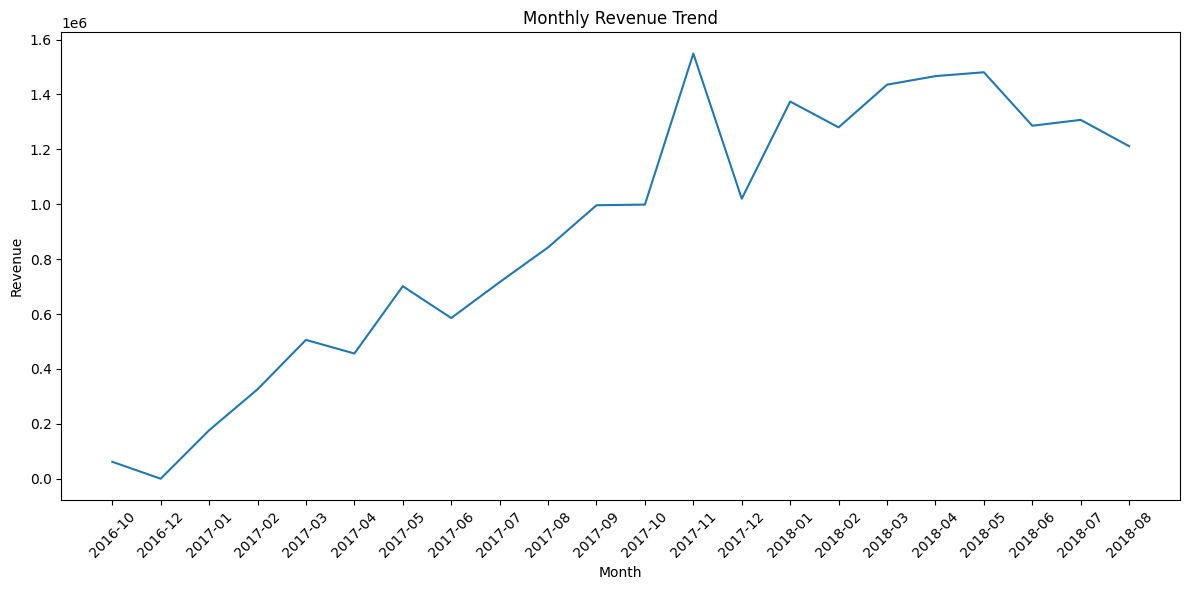

In [172]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    monthly_revenue['purchase_month'],
    monthly_revenue['monthly_revenue']
)

plt.xticks(rotation=45)

plt.xlabel('Month')
plt.ylabel('Revenue')
plt.title('Monthly Revenue Trend')

plt.tight_layout()

plt.savefig(
    'monthly_revenue_trend.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Conclusions

- The ETL pipeline successfully integrated multiple e-commerce datasets into a unified analytical database.
- Revenue analysis revealed strong business growth and clear regional concentration patterns.
- Data validation and quality checks confirmed that the dataset was suitable for reporting and analytical purposes.